In [1]:
# THIS CODE USES CUPY; FOR MORE THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange
import time 

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 250 * 10**5 # In timesteps of dt
gridpoints = 1024 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 6E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2 = 1.0 / (dx * dx)

# Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23 * 0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84 * cp.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 # Number of saved values

Da = vb * cp.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [3]:
# Initializes array of density values
cp.random.seed(7) # Opens a random number generator instance, seed 7

rho = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho = cp.maximum(rho, 1.E-10) # Prevents negative densities

initial_mass = cp.sum(rho)

def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    return ( #Uses the inbuilt roll which does allow for periodic boundary conditions
        cp.roll(function_array,  1, axis=1) +
        cp.roll(function_array, -1, axis=1) +
        cp.roll(function_array,  1, axis=0) +
        cp.roll(function_array, -1, axis=0) -
        4.0 * function_array) * inv_dx2

beta_mu_kernel = cp.ElementwiseKernel(
    'float64 rho, float64 lap_rho',
    'float64 output',
    f'''
    output = 2.0 * {B2} * rho
          + log(rho)
          + {valence} * log((-1.0 + sqrt(1.0 + 16.0 * rho * {Da})) / (8.0 * rho * {Da}))
          - {K} * lap_rho;
    ''',
    'beta_mu_kernel'
)

def compute_step_single(rho):

    lap_rho = laplacian_2d(rho)
    
    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = beta_mu_kernel(rho, lap_rho)

    laplacian_2d_mu = laplacian_2d(beta_mu_total)


    return dt * M * laplacian_2d_mu


# Initializes arrays for saving rho
num_saves = duration // save_interval + 1
rho_total_array = cp.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_total_array[0] = rho
save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []

start_time = time.perf_counter()
for step in range(duration):

    # Iterates to find new value of rho
    rho += compute_step_single(rho)

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_total_array[save_index] = rho
        save_index += 1

        total_mass = cp.sum(rho)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        rho = cp.maximum(rho, floor)

        time_elapsed = time.perf_counter() - start_time
        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)} at {time_elapsed:1f} seconds")

Progress: 0.0 out of 250.0 at 0.081007 seconds
Progress: 1.0 out of 250.0 at 36.982661 seconds
Progress: 2.0 out of 250.0 at 75.710213 seconds
Progress: 3.0 out of 250.0 at 113.914214 seconds
Progress: 4.0 out of 250.0 at 152.540071 seconds
Progress: 5.0 out of 250.0 at 191.045980 seconds
Progress: 6.0 out of 250.0 at 229.525815 seconds
Progress: 7.0 out of 250.0 at 267.936894 seconds
Progress: 8.0 out of 250.0 at 306.918847 seconds
Progress: 9.0 out of 250.0 at 342.649243 seconds
Progress: 10.0 out of 250.0 at 378.779313 seconds
Progress: 11.0 out of 250.0 at 414.795329 seconds
Progress: 12.0 out of 250.0 at 451.380326 seconds
Progress: 13.0 out of 250.0 at 489.094610 seconds
Progress: 14.0 out of 250.0 at 527.408892 seconds
Progress: 15.0 out of 250.0 at 565.955822 seconds
Progress: 16.0 out of 250.0 at 604.299461 seconds
Progress: 17.0 out of 250.0 at 643.129850 seconds
Progress: 18.0 out of 250.0 at 681.357829 seconds
Progress: 19.0 out of 250.0 at 720.282000 seconds
Progress: 20.0

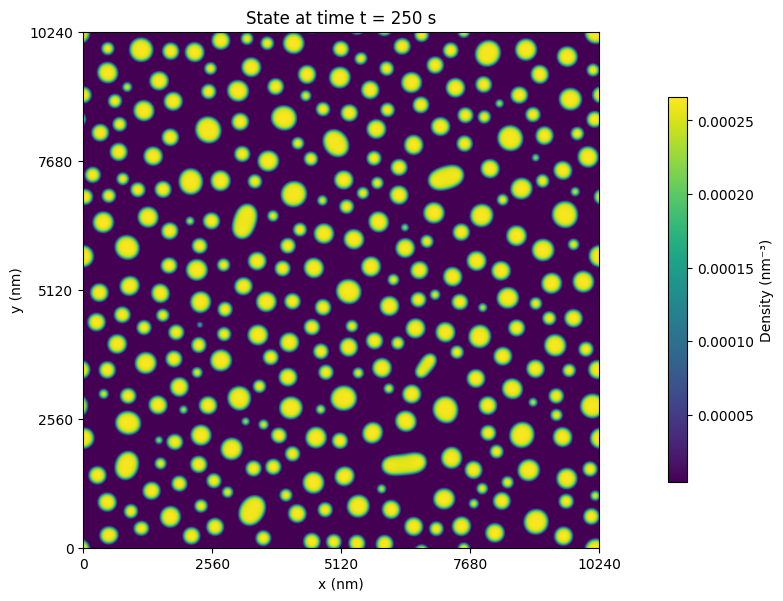

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
rho_np = rho_total_array.get()

vmin, vmax = rho_np.min(), rho_np.max()
t_final = (save_index - 1) * save_interval * dt

im = ax.imshow(rho_np[save_index - 1], origin='lower', cmap='viridis',
               vmin=vmin, vmax=vmax,
               extent=[0, grid_length, 0, grid_length])
fig.colorbar(im, ax=ax, label="Density (nm⁻³)", shrink = 0.5, pad = 0.1)
ax.set_title(f"State at time t = {t_final:.0f} s")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_xticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])
ax.set_yticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])


plt.tight_layout()
plt.savefig("rho_final.png", dpi=150)
plt.show()

In [5]:
def find_perimeter(rho):

    # Creates binary array: 0 for pixel in dilute phase, 1 for pixel in dense phase
    threshold = (rho.max() + rho.min()) / 2
    binary_mask = (rho >= threshold).astype(int)

    # Pads with periodic boundaries
    padded = np.pad(binary_mask, pad_width=1, mode='wrap')

    # Checks to see if each pixel has at least one dilute neighbor
    neighbor_sum = (padded[:-2, 1:-1] + padded[2:,  1:-1] + padded[1:-1, :-2] + padded[1:-1, 2:])

    # Finds dense pixels with dilute neighbors + counts
    interface_mask = (binary_mask == 1) & (neighbor_sum < 4)
    interface_count = int(interface_mask.sum())

    return binary_mask, interface_mask, interface_count


def calc_free_energy(rho, Xa, v0 = 1):
    '''
    Finds free energy of a system using F = integral_V [ f({rho_i}) + K/2 sum_i (gradient rho)^2 ] dV

    Using f_ref = rho * log(v_0 * rho) - rho + B2 * rho^2 + {sum_i [rho_i log(rho_i/rho_tot)]}

    The last term will always be 0 for a 1-component system (log 1 = 0), so it not included here

    Using f_b = rho_A * valence * (log(Xa) + (1-Xa)/2)
    
    Note that this will vary by mixture-- eq shown is for AAAA only
    '''

    # Floors rho to prevent error
    rho_floored = np.maximum(rho, floor)

    # Finds f_ref and f_b
    f_ref = rho_floored * np.log(v0 * rho_floored) - rho_floored + B2 * rho_floored**2
    f_b = rho_floored * 4 * (np.log(Xa) + (1-Xa)/2)

    # Finds the local free energy at each point (f{rho_i})
    f_local = f_ref + f_b
    
    # Calculates the gradient term K/2 * (gradient rho)^2
    grad_x, grad_y = np.gradient(rho)
    f_gradient = 0.5 * K * (grad_x**2 + grad_y**2)
    
    # Total free energy density
    f_total = f_local + f_gradient
    
    # Integrate over volume in 1D (multiply by dx and sum)
    F_total = np.trapezoid(np.trapezoid(f_total, dx=dx, axis= 1), axis = 0)
    
    return F_total

In [ ]:
#Finds interfacial area for rho and floors it
binary_mask, interface_mask, interface_count = find_perimeter(rho_np)
interfacial_area = interface_count * dx
rho_floored = np.maximum(rho_np, floor)

# Extracts dilute/dense phase densities and creates homogenous systems
rho_dilute = np.min(rho_floored) 
rho_dense = np.max(rho_floored)

rho_dilute_system = np.full((gridpoints, gridpoints), rho_dilute)
rho_dense_system = np.full((gridpoints, gridpoints), rho_dense)

# Finds Xa for dilute, dense, and coex
CaDa = 4*rho_floored*Da
Xa = (-1 + np.sqrt(1 + 4 * CaDa)) / (2 * CaDa)
Xa_final_coex = np.maximum(Xa, floor) 

CaDa_dilute = 4*rho_dilute_system*Da
CaDa_dilute_floored = np.maximum(CaDa_dilute, floor)
Xa_final_dilute = (-1 + np.sqrt(1 + 4 * CaDa_dilute_floored)) / (2 * CaDa_dilute_floored)

CaDa_dense = 4*rho_dense_system*Da
CaDa_dense_floored = np.maximum(CaDa_dense, floor)
Xa_final_dense = (-1 + np.sqrt(1 + 4 * CaDa_dense_floored)) / (2 * CaDa_dense_floored)

# Finds free energy of dilute, dense, and coexisting systems
F_dilute = calc_free_energy(rho_dilute_system, Xa_final_dilute)
F_dense = calc_free_energy(rho_dense_system, Xa_final_dense)
F_coex = calc_free_energy(rho_floored, Xa_final_coex)

surface_tension = (F_coex - F_dilute - F_dense) / (interfacial_area)
print(f"The surface tension is {surface_tension:.6e} for T = {T} in a 2D system with 1 component, initialized with a uniform distribution")